# Access MODIS Aqua L2 Ocean Color Data

This notebook demonstrates how to:
1. Query MODIS Aqua L2 ocean color data from OB.DAAC via EarthAccess
2. Filter by time range, bounding box, and cloud cover
3. Download granules
4. Load and examine Rrs (remote sensing reflectance) data
5. Work with L2 quality flags
6. Extract Rrs spectra at specific locations

**Requirements:**
- EarthData login credentials (create account at https://urs.earthdata.nasa.gov/)
- Internet connection

**MODIS Aqua L2 OC Products:**
- Collection: `MODISA_L2_OC` (standard) or `MODISA_L2_OC_NRT` (near-real-time)
- Rrs wavelengths: 412, 443, 469, 488, 531, 547, 555, 645, 667, 678 nm

In [1]:
# Imports
from importlib import reload
import os
import numpy as np

import earthaccess

from matplotlib import pyplot as plt

from remote_sensing.download import earthaccess as ea
from remote_sensing.netcdf import oc

/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
# 1. EarthData Login

Authentication is required to access OB.DAAC data. The `earthaccess` library handles credentials via:
1. Environment variables (`EARTHDATA_USERNAME`, `EARTHDATA_PASSWORD`)
2. `.netrc` file
3. Interactive prompt

In [2]:
# Login to EarthData
earthaccess.login()

---
# 2. Query MODIS L2 Ocean Color Data

## 2.1 Basic Query

Query granules using:
- `time_range`: Temporal extent as `(start, end)` strings
- `bbox`: Bounding box as `(lon_min, lat_min, lon_max, lat_max)`

In [3]:
# Define search parameters
time_range = ('2024-01-15', '2024-01-16')
bbox = (127, 18, 134, 23)  # Japan region: lon_min, lat_min, lon_max, lat_max

In [4]:
# Query standard (reprocessed) MODIS L2 OC data
granules = ea.query_modis_oc(
    time_range=time_range,
    bbox=bbox,
    nrt=False,  # Standard processing
    verbose=True
)

print(f"\nFound {len(granules)} standard MODIS L2 OC granules")

Querying MODISA_L2_OC from OB.DAAC
  Time range: 2024-01-15 to 2024-01-16
  Bounding box: lon=[127, 134], lat=[18, 23]
Found 2 granules

Found 2 standard MODIS L2 OC granules


## 2.2 Query Near-Real-Time (NRT) Data

NRT data is available with lower latency but may have less refined calibration.

In [5]:
# Query NRT MODIS L2 OC data
granules_nrt = ea.query_modis_oc(
    time_range=time_range,
    bbox=bbox,
    nrt=True,  # Near-real-time processing
    verbose=True
)

print(f"\nFound {len(granules_nrt)} NRT MODIS L2 OC granules")

Querying MODISA_L2_OC_NRT from OB.DAAC
  Time range: 2024-01-15 to 2024-01-16
  Bounding box: lon=[127, 134], lat=[18, 23]
Found 0 granules

Found 0 NRT MODIS L2 OC granules


## 2.3 Filter by Cloud Cover

Reduce downloads by filtering for low cloud cover scenes.

In [6]:
# Query with strict cloud cover filter (0-20%)
granules_clear = ea.query_modis_oc(
    time_range=time_range,
    bbox=bbox,
    cloud_cover=(0, 20),  # Low cloud cover only
    verbose=True
)

print(f"\nFound {len(granules_clear)} clear-sky granules")

Querying MODISA_L2_OC from OB.DAAC
  Time range: 2024-01-15 to 2024-01-16
  Bounding box: lon=[127, 134], lat=[18, 23]
  Cloud cover: 0-20%
Found 0 granules

Found 0 clear-sky granules


In [7]:
# Query with relaxed cloud cover filter (0-100%)
granules_all = ea.query_modis_oc(
    time_range=time_range,
    bbox=bbox,
    cloud_cover=(0, 100),  # All cloud cover
    verbose=True
)

print(f"\nClear: {len(granules_clear)}, All: {len(granules_all)}")
print(f"Cloud filtering removed {len(granules_all) - len(granules_clear)} granules")

Querying MODISA_L2_OC from OB.DAAC
  Time range: 2024-01-15 to 2024-01-16
  Bounding box: lon=[127, 134], lat=[18, 23]
  Cloud cover: 0-100%
Found 2 granules

Clear: 0, All: 2
Cloud filtering removed 2 granules


---
# 3. Examine Granule Metadata

Build a table of granules with spatial extent, time, and cloud cover.

In [8]:
# Convert granules to dictionary format
granules_dict = ea.granules_to_dict(granules)

# Build a summary table
df = ea.build_granule_table(granules_dict, fix_antimeridian=True)
df

,id,polygon,time,CC,url
0,MODISA_L2_OC_AQUA_MODIS.20240115T045000.L2.OC....,"POLYGON ((143.37527 33.14842, 119.37357 29.669...",2024-01-15 04:52:29.500000+00:00,71.2,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...
1,MODISA_L2_OC_AQUA_MODIS.20240116T053001.L2.OC....,"POLYGON ((133.77986 27.51276, 111.02403 24.213...",2024-01-16 05:32:30.500000+00:00,85.5,https://obdaac-tea.earthdatacloud.nasa.gov/ob-...


/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/xavier/miniforge3/envs/ocean14/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', 

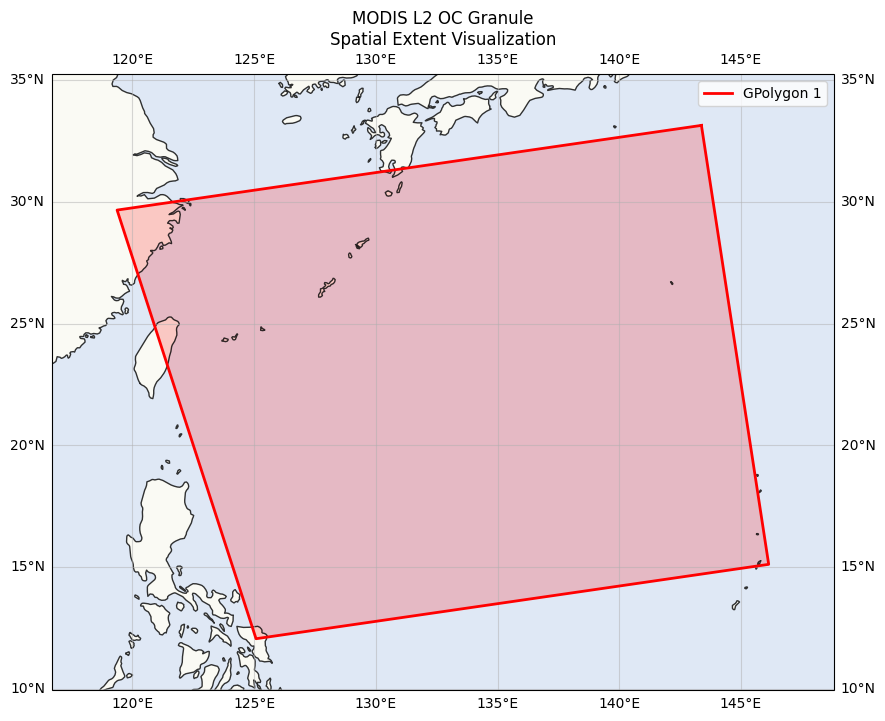

In [9]:
# Plot spatial extent of first granule
if len(granules) > 0:
    fig = ea.plot_spatial_extent(granules[0], granule_title="MODIS L2 OC Granule")

---
# 4. Download Granules

**Note:** MODIS L2 OC files are typically 50-150 MB each. Set `download_dir` to control where files are saved.

In [10]:
# Set download directory
download_dir = './MODIS_L2_OC/'

# Download only the first granule (for demo purposes)
# Uncomment to actually download
# if len(granules) > 0:
#     files = ea.download_modis_oc(
#         granules[:1],  # Download only first granule
#         download_dir=download_dir,
#         verbose=True
#     )
#     print(f"Downloaded: {files}")

---
# 5. MODIS OC Wavelengths and Variables

MODIS Aqua has 10 Rrs bands for ocean color applications.

In [11]:
# Get standard MODIS OC wavelengths
wavelengths = oc.get_wavelength_array()
print(f"MODIS OC wavelengths: {wavelengths} nm")
print(f"Number of bands: {len(wavelengths)}")

MODIS OC wavelengths: [412 443 469 488 531 547 555 645 667 678] nm
Number of bands: 10


In [12]:
# Rrs variable names in the NetCDF files
print("Rrs variable names:")
for wl in wavelengths:
    print(f"  Rrs_{wl}")

Rrs variable names:
  Rrs_412
  Rrs_443
  Rrs_469
  Rrs_488
  Rrs_531
  Rrs_547
  Rrs_555
  Rrs_645
  Rrs_667
  Rrs_678


---
# 6. L2 Quality Flags

MODIS L2 products include a 32-bit flag array (`l2_flags`) to indicate data quality issues.

In [13]:
# Show all L2 flag definitions
print("L2 Flag Definitions (bit position: flag name):\n")
for flag_name, bit_pos in sorted(oc.L2_FLAGS.items(), key=lambda x: x[1]):
    print(f"  Bit {bit_pos:2d}: {flag_name}")

L2 Flag Definitions (bit position: flag name):

  Bit  0: ATMFAIL
  Bit  1: LAND
  Bit  2: PRODWARN
  Bit  3: HIGLINT
  Bit  4: HILT
  Bit  5: HISATZEN
  Bit  6: COASTZ
  Bit  8: STRAYLIGHT
  Bit  9: CLDICE
  Bit 10: COCCOLITH
  Bit 11: TURBIDW
  Bit 12: HISOLZEN
  Bit 14: LOWLW
  Bit 15: CHLFAIL
  Bit 16: NAVWARN
  Bit 17: ABSAER
  Bit 19: MAXAERITER
  Bit 20: MODGLINT
  Bit 21: CHLWARN
  Bit 22: ATMWARN
  Bit 24: SEAICE
  Bit 25: NAVFAIL
  Bit 26: FILTER
  Bit 28: BOWTIEDEL
  Bit 29: HIPOL
  Bit 30: PRODFAIL
  Bit 31: SPARE


In [14]:
# Default flags used for conservative quality masking
print("Default mask flags (conservative):")
for flag in oc.DEFAULT_MASK_FLAGS:
    print(f"  {flag}")

Default mask flags (conservative):
  ATMFAIL
  LAND
  HILT
  HISATZEN
  STRAYLIGHT
  CLDICE
  HISOLZEN
  CHLFAIL
  NAVWARN
  NAVFAIL
  FILTER
  BOWTIEDEL
  PRODFAIL


## 6.1 Working with L2 Flags

Demonstrate flag checking with synthetic data.

In [15]:
# Create synthetic L2 flags for demonstration
l2_flags = np.zeros((100, 100), dtype=np.uint32)

# Set ATMFAIL flag (bit 0) at one location
l2_flags[10, 10] = 1 << oc.L2_FLAGS['ATMFAIL']

# Set LAND flag (bit 1) at another location
l2_flags[20, 20] = 1 << oc.L2_FLAGS['LAND']

# Set both ATMFAIL and LAND at a third location
l2_flags[30, 30] = (1 << oc.L2_FLAGS['ATMFAIL']) | (1 << oc.L2_FLAGS['LAND'])

print("Synthetic flags set at (10,10), (20,20), (30,30)")

Synthetic flags set at (10,10), (20,20), (30,30)


In [16]:
# Check ATMFAIL flag
atmfail_mask = oc.check_flag(l2_flags, 'ATMFAIL')

print("ATMFAIL flag status:")
print(f"  (10,10): {atmfail_mask[10, 10]}  # Should be True")
print(f"  (20,20): {atmfail_mask[20, 20]}  # Should be False (only LAND)")
print(f"  (30,30): {atmfail_mask[30, 30]}  # Should be True (both flags)")

ATMFAIL flag status:
  (10,10): True  # Should be True
  (20,20): False  # Should be False (only LAND)
  (30,30): True  # Should be True (both flags)


In [17]:
# Check LAND flag
land_mask = oc.check_flag(l2_flags, 'LAND')

print("LAND flag status:")
print(f"  (10,10): {land_mask[10, 10]}  # Should be False (only ATMFAIL)")
print(f"  (20,20): {land_mask[20, 20]}  # Should be True")
print(f"  (30,30): {land_mask[30, 30]}  # Should be True (both flags)")

LAND flag status:
  (10,10): False  # Should be False (only ATMFAIL)
  (20,20): True  # Should be True
  (30,30): True  # Should be True (both flags)


## 6.2 Create Quality Mask

Combine multiple flags into a single quality mask.

In [18]:
# Create synthetic flags with different quality issues
l2_flags = np.zeros((100, 100), dtype=np.uint32)

# Set ATMFAIL in one region
l2_flags[:10, :] = 1 << oc.L2_FLAGS['ATMFAIL']

# Set LAND in another region
l2_flags[20:30, :] = 1 << oc.L2_FLAGS['LAND']

# Set CLDICE in another region
l2_flags[40:50, :] = 1 << oc.L2_FLAGS['CLDICE']

print("Synthetic flags:")
print("  Rows 0-9: ATMFAIL")
print("  Rows 20-29: LAND")
print("  Rows 40-49: CLDICE")
print("  Rows 60-69: Clean (no flags)")

Synthetic flags:
  Rows 0-9: ATMFAIL
  Rows 20-29: LAND
  Rows 40-49: CLDICE
  Rows 60-69: Clean (no flags)


In [19]:
# Create quality mask (conservative)
mask = oc.create_quality_mask(l2_flags, verbose=True)

print(f"\nMask statistics:")
print(f"  ATMFAIL region masked: {np.all(mask[:10, :])}")
print(f"  LAND region masked: {np.all(mask[20:30, :])}")
print(f"  CLDICE region masked: {np.all(mask[40:50, :])}")
print(f"  Clean region masked: {np.all(mask[60:70, :])}  # Should be False")

  ATMFAIL: 1000 pixels (10.0%)
  LAND: 1000 pixels (10.0%)
  HILT: 0 pixels (0.0%)
  HISATZEN: 0 pixels (0.0%)
  STRAYLIGHT: 0 pixels (0.0%)
  CLDICE: 1000 pixels (10.0%)
  HISOLZEN: 0 pixels (0.0%)
  CHLFAIL: 0 pixels (0.0%)
  NAVWARN: 0 pixels (0.0%)
  NAVFAIL: 0 pixels (0.0%)
  FILTER: 0 pixels (0.0%)
  BOWTIEDEL: 0 pixels (0.0%)
  PRODFAIL: 0 pixels (0.0%)
Total masked: 3000 pixels (30.0%)

Mask statistics:
  ATMFAIL region masked: True
  LAND region masked: True
  CLDICE region masked: True
  Clean region masked: False  # Should be False


## 6.3 Conservative vs Permissive Masking

In [20]:
# Create flags with HISOLZEN (high solar zenith - included in conservative but not always critical)
l2_flags_solzen = np.ones((100, 100), dtype=np.uint32) * (1 << oc.L2_FLAGS['HISOLZEN'])

# Conservative masking (default)
conservative_mask = oc.create_quality_mask(l2_flags_solzen)

# Permissive masking (only critical flags)
permissive_mask = oc.create_quality_mask(
    l2_flags_solzen,
    mask_flags=['ATMFAIL', 'LAND', 'CLDICE']  # Minimal flags
)

print(f"Conservative masking: {np.sum(conservative_mask)} pixels masked")
print(f"Permissive masking: {np.sum(permissive_mask)} pixels masked")
print(f"\nConservative masks HISOLZEN, permissive does not.")

Conservative masking: 10000 pixels masked
Permissive masking: 0 pixels masked

Conservative masks HISOLZEN, permissive does not.


---
# 7. Extract Rrs Spectrum

Demonstrate extracting an Rrs spectrum at a specific pixel location.

In [21]:
# Create synthetic Rrs data (simulating ocean color spectrum)
wavelengths = oc.get_wavelength_array()
rrs_dict = {}

for wl in wavelengths:
    # Create synthetic spectrum: higher Rrs at shorter wavelengths (typical blue water)
    rrs_dict[wl] = np.ones((100, 100)) * (600.0 / wl) * 0.01

print(f"Created synthetic Rrs data at {len(wavelengths)} wavelengths")
print(f"Shape: {rrs_dict[412].shape}")

Created synthetic Rrs data at 10 wavelengths
Shape: (100, 100)


In [22]:
# Extract spectrum at a specific pixel
row, col = 50, 50
wl_out, rrs_out = oc.extract_rrs_spectrum(rrs_dict, row, col)

print(f"Extracted spectrum at pixel ({row}, {col}):")
print(f"  Wavelengths: {wl_out} nm")
print(f"  Rrs values: {np.round(rrs_out, 4)} sr^-1")

Extracted spectrum at pixel (50, 50):
  Wavelengths: [412 443 469 488 531 547 555 645 667 678] nm
  Rrs values: [0.0146 0.0135 0.0128 0.0123 0.0113 0.011  0.0108 0.0093 0.009  0.0088] sr^-1


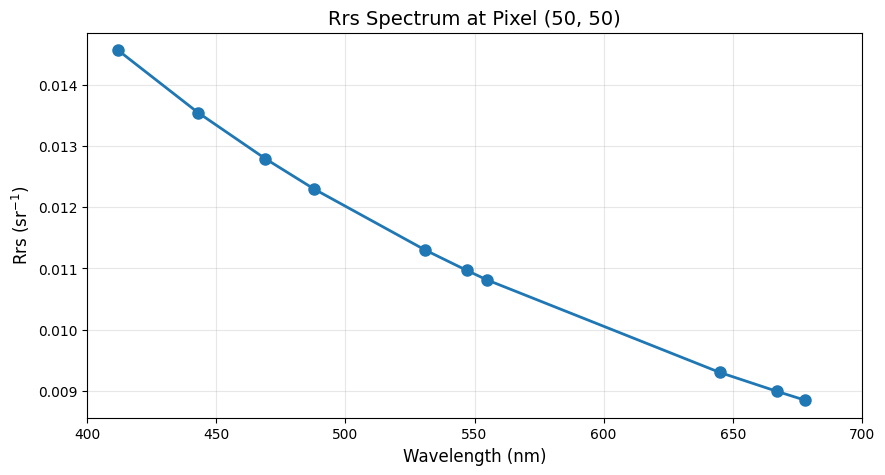

In [23]:
# Plot the spectrum
plt.figure(figsize=(10, 5))
plt.plot(wl_out, rrs_out, 'o-', linewidth=2, markersize=8)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Rrs (sr$^{-1}$)', fontsize=12)
plt.title(f'Rrs Spectrum at Pixel ({row}, {col})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(400, 700)
plt.show()

---
# 8. Load Real MODIS L2 OC File

If you have downloaded a file, load and examine it here.

The `oc.load()` function returns:
- `rrs_dict`: Dictionary of Rrs arrays keyed by wavelength
- `l2_flags`: Quality flags (32-bit)
- `latitude`, `longitude`: Navigation data
- `time`: Observation time

In [ ]:
# Example: Load a downloaded file
# Uncomment and modify path as needed

# modis_file = './MODIS_L2_OC/AQUA_MODIS.20240115T012000.L2.OC.nc'
# 
# rrs_dict, l2_flags, lat, lon, time = oc.load(modis_file, verbose=True)
# 
# if rrs_dict is not None:
#     print(f"\nLoaded file: {os.path.basename(modis_file)}")
#     print(f"  Rrs bands: {list(rrs_dict.keys())} nm")
#     print(f"  Shape: {lat.shape}")
#     print(f"  Time: {time}")
#     print(f"  Lat range: {lat.min():.2f} to {lat.max():.2f}")
#     print(f"  Lon range: {lon.min():.2f} to {lon.max():.2f}")

In [ ]:
# Example: Apply quality mask and extract clean spectrum
# Uncomment if you have loaded a real file

# # Create quality mask
# mask = oc.create_quality_mask(l2_flags, verbose=True)
# 
# # Find a clean pixel (not masked)
# clean_pixels = np.where(~mask)
# if len(clean_pixels[0]) > 0:
#     row, col = clean_pixels[0][0], clean_pixels[1][0]
#     wl, rrs = oc.extract_rrs_spectrum(rrs_dict, row, col)
#     print(f"\nClean pixel at ({row}, {col}):")
#     print(f"  Location: {lat[row, col]:.2f}N, {lon[row, col]:.2f}E")
#     
#     # Plot
#     plt.figure(figsize=(10, 5))
#     plt.plot(wl, rrs, 'o-', linewidth=2, markersize=8)
#     plt.xlabel('Wavelength (nm)')
#     plt.ylabel('Rrs (sr$^{-1}$)')
#     plt.title(f'MODIS Rrs Spectrum at {lat[row, col]:.2f}N, {lon[row, col]:.2f}E')
#     plt.grid(True, alpha=0.3)
#     plt.show()

---
# Summary

This notebook demonstrated:

1. **EarthData Authentication**: Using `earthaccess.login()` for OB.DAAC access

2. **Querying MODIS L2 OC**:
   - Standard vs NRT collections
   - Filtering by time, bounding box, and cloud cover

3. **Granule Metadata**: Extracting spatial extent, time, and cloud cover

4. **L2 Quality Flags**:
   - 32-bit bitmask with ~30 quality indicators
   - `check_flag()` for individual flags
   - `create_quality_mask()` for combining multiple flags
   - Conservative vs permissive masking strategies

5. **Rrs Data**:
   - 10 ocean color wavelengths (412-678 nm)
   - `extract_rrs_spectrum()` for spectral analysis

**Key Functions:**
- `ea.query_modis_oc()` - Query granules
- `ea.download_modis_oc()` - Download files
- `oc.load()` - Load NetCDF file
- `oc.check_flag()` - Check individual flags
- `oc.create_quality_mask()` - Create combined mask
- `oc.extract_rrs_spectrum()` - Extract spectrum at pixel